Copyright 2025 Kevin Zambello

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import sys

sys.path.insert(1, '../..')

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import scipy.special

import cpadenn
from cpadenn import Layers, Models, Utils

2025-11-07 11:04:43.677185: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-07 11:04:43.678323: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-07 11:04:43.684553: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-07 11:04:43.702941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762509883.734558 1209670 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762509883.74

In [2]:
def n_thirring1d(mu, beta=1.0, L=8.0, m=2.0):

    mu = np.complex128(mu)

    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)
    
    res = I1**L * np.sinh(L*mu)
    res = res / (I1**L * np.cosh(L*mu) + I0**L * np.cosh(mtilde))

    return res

In [3]:
def n_thirring1d_sing(beta=1.0, L=8.0, m=2.0):
    
    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)

    res = (1.0/L) * np.acosh(   np.complex128(- I0**L / I1**L * np.cosh(mtilde))   )
    
    res_arr = res + np.array([1.0j*2.0*np.pi*n/L for n in range(-5,5)])
    res_arr = np.append(res_arr, -res_arr)

    return res_arr

Text(0.5, 0, '$Re[\\mu]$')

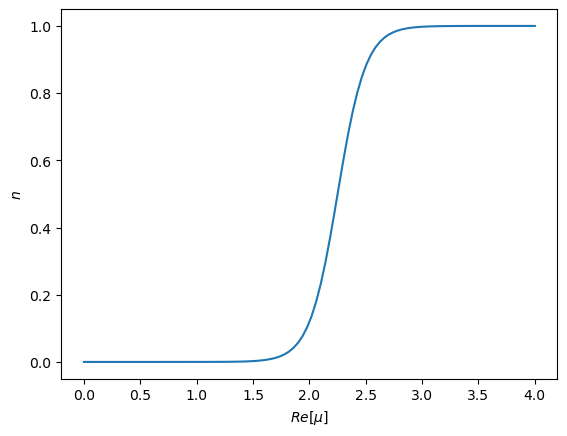

In [4]:
mymu = np.linspace(0., 4., 100)
plt.plot(mymu, n_thirring1d(mymu).real)
plt.ylabel('$n$')
plt.xlabel('$Re[\mu]$')

In [5]:
n_thirring1d_sing()

array([ 2.25019782-3.53429174j,  2.25019782-2.74889357j,
        2.25019782-1.96349541j,  2.25019782-1.17809725j,
        2.25019782-0.39269908j,  2.25019782+0.39269908j,
        2.25019782+1.17809725j,  2.25019782+1.96349541j,
        2.25019782+2.74889357j,  2.25019782+3.53429174j,
       -2.25019782+3.53429174j, -2.25019782+2.74889357j,
       -2.25019782+1.96349541j, -2.25019782+1.17809725j,
       -2.25019782+0.39269908j, -2.25019782-0.39269908j,
       -2.25019782-1.17809725j, -2.25019782-1.96349541j,
       -2.25019782-2.74889357j, -2.25019782-3.53429174j])

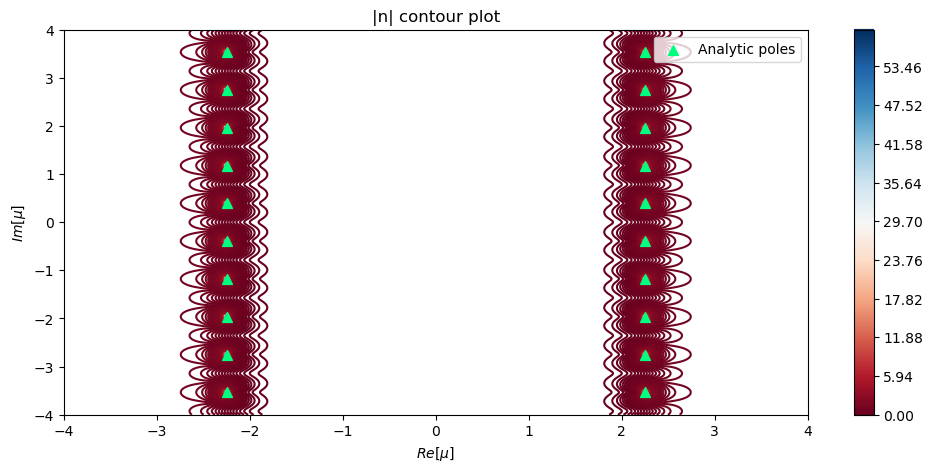

In [6]:
pts = 500
xg = np.linspace(-4, 4, pts)
yg = np.linspace(-4, 4, pts)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg + 1.0j*Yg
out = n_thirring1d(Zg)

real_out = out.reshape(Xg.shape)
imag_out = out.imag.reshape(Yg.shape)
abs_out = np.abs(real_out + 1.0j * imag_out)

analytic_sings = n_thirring1d_sing()

plt.figure(figsize=(12, 5))
plt.contour(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
#plt.contourf(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
plt.colorbar()
plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$Im[\mu]$')
plt.title('|n| contour plot')
plt.legend()

Text(0.5, 1.0, 'Test data')

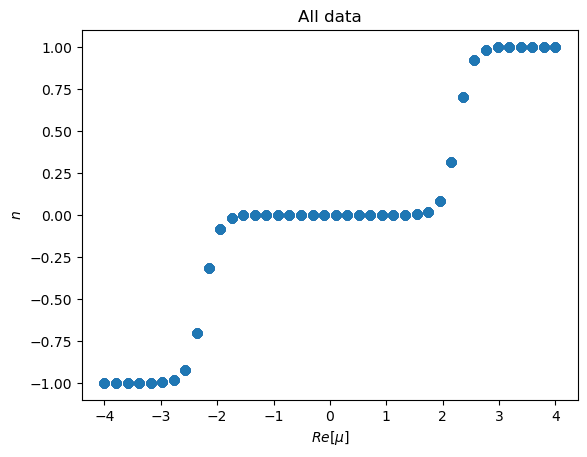

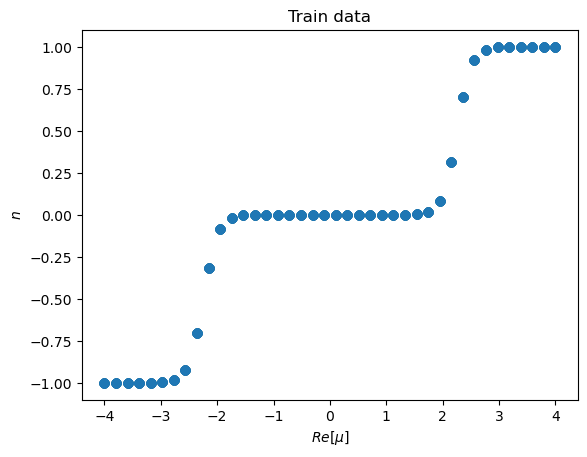

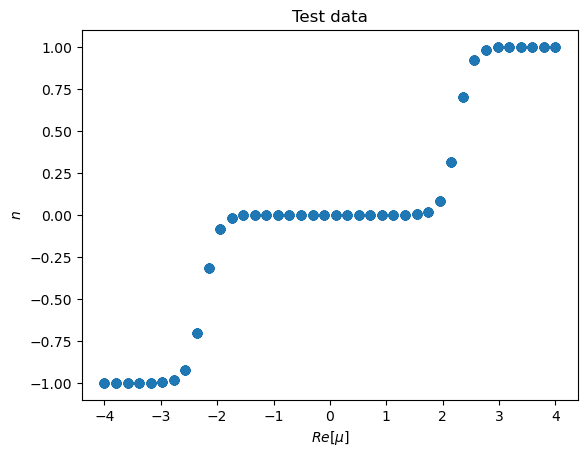

In [7]:
epsilon = 1.0e-6

mu_ = np.linspace(-4.0,4.0,40)
n_ = n_thirring1d(mu_)
dn_ = np.abs(n_) * epsilon

mu_sampled = mu_ 
n_sampled = n_ + dn_*np.random.randn(dn_.size)

for n in np.arange(100):
    mu_sampled = np.append(mu_sampled, mu_)
    n_sampled = np.append(n_sampled, n_ + dn_*np.random.randn(dn_.size))
    
X = np.transpose(np.stack([np.real(mu_sampled), np.imag(mu_sampled)]))
Y = np.transpose(np.stack([np.real(n_sampled), np.imag(n_sampled)]))

plt.figure()
plt.plot(X[:,0], Y[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('All data')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state=42)

plt.figure()
plt.plot(X_train[:,0], Y_train[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Train data')

plt.figure()
plt.plot(X_test[:,0], Y_test[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Test data')

In [8]:
modelNN_run1 = cpadenn.Models.PadeModel(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run1.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_run1 = modelNN_run1.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_run1.summary())

Epoch 1/2000


2025-11-07 11:04:56.085402: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 2.3652 - val_loss: 0.8233
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6646 - val_loss: 0.4306
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3538 - val_loss: 0.2676
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2255 - val_loss: 0.1983
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1785 - val_loss: 0.1592
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1474 - val_loss: 0.1374
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1326 - val_loss: 0.1236
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1205 - val_loss: 0.1137
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1114 - val_loss: 0.1069
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1049 - val_loss: 0.1021
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1003 - val_loss: 0.0983
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0715 - val_loss: 0.0713
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0712 - val_loss: 0.0710
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0710 - val_loss: 0.0707
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0706 - val_loss: 0.0704
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0704 - val_loss: 0.0702
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0700 - val_loss: 0.0699
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0698 - val_loss: 0.0696
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0695 - val_loss: 0.0694
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0692 - val_loss: 0.0690
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0689 - val_loss: 0.0688
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0686 - val_loss: 0.0685
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0517 - val_loss: 0.0515
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0514 - val_loss: 0.0512
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0511 - val_loss: 0.0509
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0508 - val_loss: 0.0506
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0505 - val_loss: 0.0503
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0502 - val_loss: 0.0500
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0499 - val_loss: 0.0497
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0495 - val_loss: 0.0494
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0493 - val_loss: 0.0491
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0490 - val_loss: 0.0488
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0487 - val_loss: 0.0485
Epoch 146/2000
23/23 

...

 Total params: 452 (1.77 KB)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302 (1.18 KB)

None


In [9]:
modelNN_run2 = cpadenn.Models.PadeModel(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run2.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_run2 = modelNN_run2.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_run2.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 4.3800 - val_loss: 0.6021
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5018 - val_loss: 0.3395
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3279 - val_loss: 0.2681
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2657 - val_loss: 0.2272
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2203 - val_loss: 0.1945
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1839 - val_loss: 0.1685
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1607 - val_loss: 0.1481
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1405 - val_loss: 0.1349
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1285 - val_loss: 0.1259
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1206 - val_loss: 0.1197
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1160 - val_loss: 0.1163
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0768 - val_loss: 0.0775
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0769 - val_loss: 0.0770
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0766 - val_loss: 0.0767
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0764 - val_loss: 0.0816
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0800 - val_loss: 0.0770
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0761 - val_loss: 0.0767
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0758 - val_loss: 0.0760
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0760 - val_loss: 0.0758
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0755 - val_loss: 0.0772
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0760 - val_loss: 0.0767
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0755 - val_loss: 0.0764
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0642 - val_loss: 0.0639
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0637 - val_loss: 0.0646
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0637 - val_loss: 0.0643
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0639 - val_loss: 0.0645
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0638 - val_loss: 0.0631
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0628 - val_loss: 0.0631
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0631 - val_loss: 0.0638
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0631 - val_loss: 0.0625
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0622 - val_loss: 0.0623
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0622 - val_loss: 0.0620
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0621 - val_loss: 0.0618
Epoch 146/2000
23/23 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0488 - val_loss: 0.0496
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0487 - val_loss: 0.0485
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0484 - val_loss: 0.0482
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0480 - val_loss: 0.0481
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0479 - val_loss: 0.0477
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0476 - val_loss: 0.0475
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0473 - val_loss: 0.0479
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0475 - val_loss: 0.0471
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0468 - val_loss: 0.0470
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0468 - val_loss: 0.0466
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0463 - val_loss: 0.0463
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0321 - val_loss: 0.0319
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0318 - val_loss: 0.0318
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0316 - val_loss: 0.0313
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0313 - val_loss: 0.0312
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0310 - val_loss: 0.0308
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0308 - val_loss: 0.0306
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0305 - val_loss: 0.0304
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0303 - val_loss: 0.0303
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0301 - val_loss: 0.0299
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0298 - val_loss: 0.0296
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0295 - val_loss: 0.0294
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 452 (1.77 KB)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302 (1.18 KB)

None


In [10]:
modelNN_baseline1 = cpadenn.Models.BaselineModel1(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_baseline1.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_baseline1 = modelNN_baseline1.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_baseline1.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 5.0362 - val_loss: 3.4501
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.0757 - val_loss: 2.2513
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0349 - val_loss: 1.4353
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2602 - val_loss: 0.8477
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7370 - val_loss: 0.5127
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4555 - val_loss: 0.3452
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3125 - val_loss: 0.2680
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2591 - val_loss: 0.2314
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2152 - val_loss: 0.2110
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1967 - val_loss: 0.1964
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1894 - val_loss: 0.1859
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0997 - val_loss: 0.0999
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0988 - val_loss: 0.0995
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0982 - val_loss: 0.0989
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0981 - val_loss: 0.0984
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0973 - val_loss: 0.0978
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0970 - val_loss: 0.0973
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0961 - val_loss: 0.0969
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0957 - val_loss: 0.0964
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0950 - val_loss: 0.0960
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0956 - val_loss: 0.0955
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0946 - val_loss: 0.0950
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/st

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0715 - val_loss: 0.0721
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0712 - val_loss: 0.0720
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0709 - val_loss: 0.0715
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0706 - val_loss: 0.0713
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0707 - val_loss: 0.0711
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0705 - val_loss: 0.0706
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0699 - val_loss: 0.0703
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0697 - val_loss: 0.0700
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0694 - val_loss: 0.0696
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0688 - val_loss: 0.0694
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0682 - val_loss: 0.0691
Epoch 146/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0545 - val_loss: 0.0542
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0535 - val_loss: 0.0539
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0537 - val_loss: 0.0536
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0535 - val_loss: 0.0535
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0532 - val_loss: 0.0532
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0529 - val_loss: 0.0530
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0529 - val_loss: 0.0528
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0525 - val_loss: 0.0525
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0522 - val_loss: 0.0524
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0526 - val_loss: 0.0521
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0518 - val_loss: 0.0520
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0405 - val_loss: 0.0408
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0405 - val_loss: 0.0407
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0404 - val_loss: 0.0405
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0402 - val_loss: 0.0403
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0403 - val_loss: 0.0401
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0395 - val_loss: 0.0400
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0399 - val_loss: 0.0399
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0394 - val_loss: 0.0397
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0394 - val_loss: 0.0395
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0393 - val_loss: 0.0393
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0390 - val_loss: 0.0391
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 344 (1.35 KB)

 Trainable params: 114 (456.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 230 (924.00 B)

None


In [11]:
modelNN_baseline2 = cpadenn.Models.BaselineModel2(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_baseline2.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_baseline2 = modelNN_baseline2.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_baseline2.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 30.2831 - val_loss: 21.3308
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.5148 - val_loss: 14.8891
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.6444 - val_loss: 10.7006
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.7450 - val_loss: 7.6004
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.8725 - val_loss: 5.3220
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.7458 - val_loss: 3.6841
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.3128 - val_loss: 2.5656
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3370 - val_loss: 1.8521
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7165 - val_loss: 1.4177
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3004 - val_loss: 1.1655
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1112 - val_loss: 1.0097
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1956 - val_loss: 0.1962
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1949 - val_loss: 0.1957
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1950 - val_loss: 0.1951
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1945 - val_loss: 0.1946
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1935 - val_loss: 0.1941
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1935 - val_loss: 0.1936
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1923 - val_loss: 0.1931
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1927 - val_loss: 0.1927
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1923 - val_loss: 0.1922
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1904 - val_loss: 0.1918
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1910 - val_loss: 0.1913
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10m

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1721 - val_loss: 0.1723
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1723 - val_loss: 0.1721
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1711 - val_loss: 0.1717
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1711 - val_loss: 0.1714
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1710 - val_loss: 0.1712
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1703 - val_loss: 0.1708
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1701 - val_loss: 0.1705
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1699 - val_loss: 0.1702
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1698 - val_loss: 0.1699
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1698 - val_loss: 0.1696
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1691 - val_loss: 0.1694
Epoch 146/2000
23/23 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1507 - val_loss: 0.1508
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1504 - val_loss: 0.1505
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1499 - val_loss: 0.1502
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1502 - val_loss: 0.1498
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1495 - val_loss: 0.1494
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1491 - val_loss: 0.1490
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1488 - val_loss: 0.1487
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1482 - val_loss: 0.1483
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1476 - val_loss: 0.1480
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1474 - val_loss: 0.1475
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1473 - val_loss: 0.1472
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1226 - val_loss: 0.1230
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1227 - val_loss: 0.1226
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1221 - val_loss: 0.1220
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1215 - val_loss: 0.1215
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1209 - val_loss: 0.1210
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1204 - val_loss: 0.1204
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1205 - val_loss: 0.1199
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1195 - val_loss: 0.1195
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1190 - val_loss: 0.1189
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1187 - val_loss: 0.1184
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1180 - val_loss: 0.1179
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 464 (1.82 KB)

 Trainable params: 154 (616.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 310 (1.21 KB)

None


Text(0, 0.5, 'Loss')

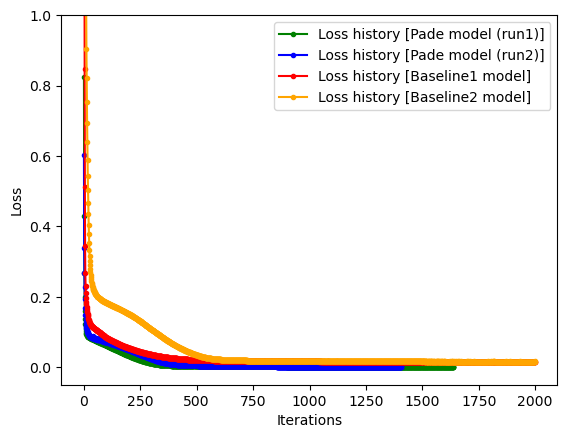

In [12]:
loss_NN_run1 = histNN_run1.history['val_loss']
loss_NN_run2 = histNN_run2.history['val_loss']
loss_NN_baseline1 = histNN_baseline1.history['val_loss']
loss_NN_baseline2 = histNN_baseline2.history['val_loss']

plt.plot(loss_NN_run1, label='Loss history [Pade model (run1)]', marker='.', color='green')
plt.plot(loss_NN_run2, label='Loss history [Pade model (run2)]', marker='.', color='blue')
plt.plot(loss_NN_baseline1, label='Loss history [Baseline1 model]', marker='.', color='red')
plt.plot(loss_NN_baseline2, label='Loss history [Baseline2 model]', marker='.', color='orange')
plt.legend()
plt.ylim([-0.05,1])
plt.xlabel('Iterations')
plt.ylabel('Loss')

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


Text(0, 0.5, '$n$')

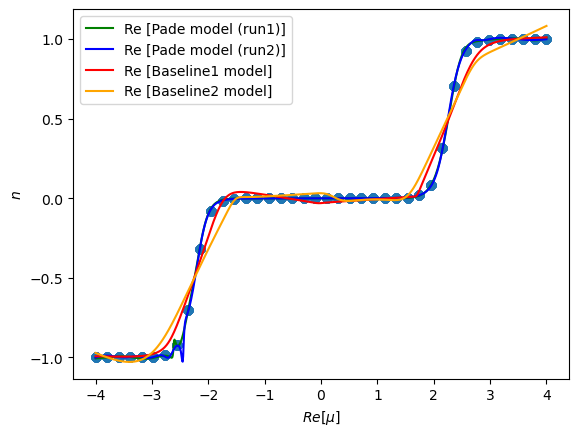

In [13]:
mu_pred = np.linspace(-4,4,1000)

X_pred = np.transpose(np.stack([np.real(mu_pred), np.imag(mu_pred)]))
Y_pred_NN_run1 = modelNN_run1.predict(X_pred)
Y_pred_NN_run2 = modelNN_run2.predict(X_pred)
Y_pred_NN_baseline1 = modelNN_baseline1.predict(X_pred)
Y_pred_NN_baseline2 = modelNN_baseline2.predict(X_pred)

plt.figure()
plt.plot(X[:,0], Y[:,0], 'o', ls='')
plt.plot(X_pred[:,0], Y_pred_NN_run1[:,0], color='green', label='Re [Pade model (run1)]')
plt.plot(X_pred[:,0], Y_pred_NN_run2[:,0], color='blue', label='Re [Pade model (run2)]')
plt.plot(X_pred[:,0], Y_pred_NN_baseline1[:,0], color='red', label='Re [Baseline1 model]')
plt.plot(X_pred[:,0], Y_pred_NN_baseline2[:,0], color='orange', label='Re [Baseline2 model]')
plt.legend()
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


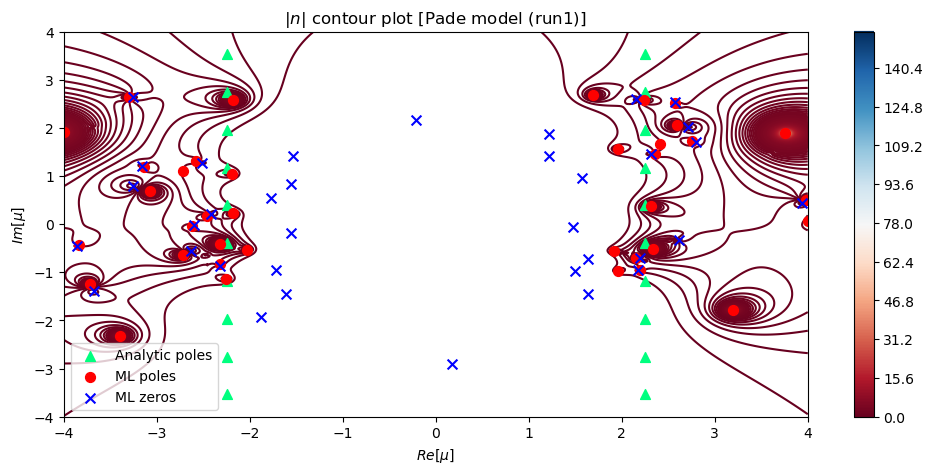

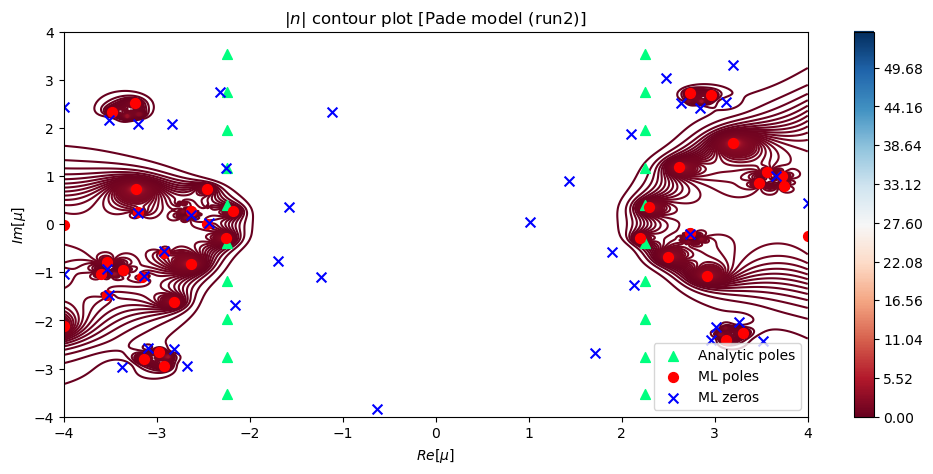

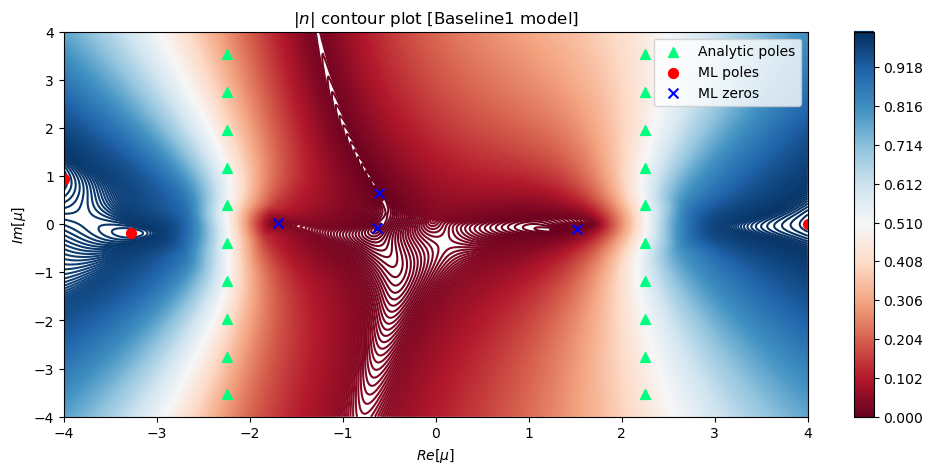

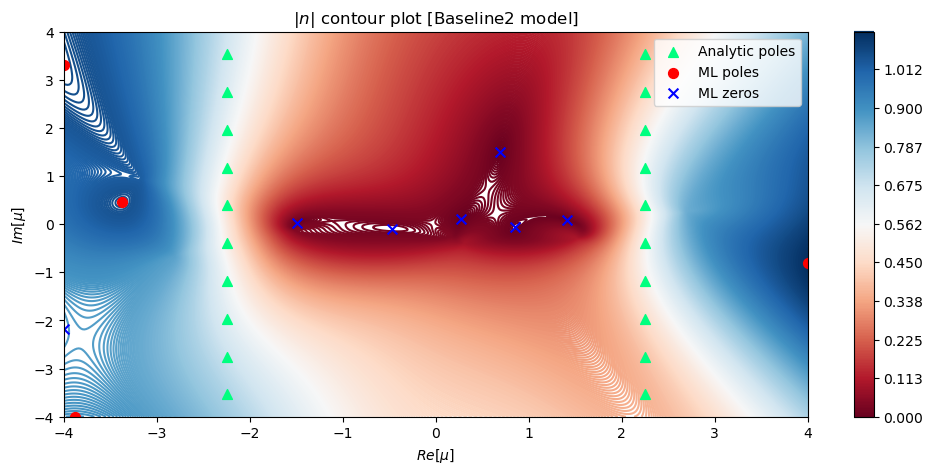

In [14]:
models = [modelNN_run1, modelNN_run2, modelNN_baseline1, modelNN_baseline2]
names = ['Pade model (run1)', 'Pade model (run2)', 'Baseline1 model', 'Baseline2 model']
for n in np.arange(4):
    pts = 400
    xg = np.linspace(-4, 4, pts)
    yg = np.linspace(-4, 4, pts)
    Xg, Yg = np.meshgrid(xg, yg)
    Zg = np.stack([Xg.ravel(), Yg.ravel()], axis=-1).astype(np.float32)
    out = models[n].predict(Zg)

    real_out = out[:, 0].reshape(Xg.shape)
    imag_out = out[:, 1].reshape(Yg.shape)
    abs_out = np.abs(real_out + 1.0j * imag_out)

    poles = cpadenn.Utils.FindLocMax(Xg, Yg, abs_out)
    zeros = cpadenn.Utils.FindLocMax(Xg, Yg, 1.0/abs_out)

    analytic_sings = n_thirring1d_sing()

    plt.figure(figsize=(12, 5))
    plt.contour(Xg, Yg, abs_out, levels=800, cmap='RdBu')
    #plt.contourf(Xg, Yg, abs_out, levels=800, cmap='RdBu')
    plt.colorbar()
    plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
    plt.scatter(poles[:,0], poles[:,1], color='red', marker='o', s=50, zorder=2, label='ML poles')
    plt.scatter(zeros[:,0], zeros[:,1], color='blue', marker='x', s=50, zorder=2, label='ML zeros')
    plt.xlabel('$Re[\mu]$')
    plt.ylabel('$Im[\mu]$')
    plt.title(f"$|n|$ contour plot [{names[n]}]")
    plt.legend()